# **Deep Q-Learning with Atari Pong**
## LLM Agents & Deep Q-Learning Assignment

**Author:** Rahul Manohar

---

## Overview

This notebook implements a Deep Q-Learning agent that learns to play Atari Pong from raw pixel inputs. The agent starts with zero knowledge and learns to consistently beat the built-in AI opponent through trial-and-error interaction with the environment.

**Key Results:**
- Baseline agent achieves an average evaluation reward of +12.4 (winning consistently)
- Training progressed from -21 (losing every point) to winning over 500 episodes
- Four ablation studies demonstrate the impact of learning rate, discount factor, exploration strategy, and decay rate on performance

**Note on episode count:** The assignment suggests 5,000 episodes as an example for simpler environments using tabular Q-learning. For Deep Q-Learning on Atari, each episode involves thousands of neural network forward/backward passes on 84x84 pixel inputs, making it orders of magnitude more computationally expensive. Our 500 episodes produced 963,799 total training steps and demonstrated clear learning progression, confirming successful training.

## Table of Contents
1. Setup and Dependencies
2. DQN Architecture, Replay Buffer, and Agent Implementation
3. Environment Analysis
4. Reward Structure
5. Baseline Training and Evaluation
6. Bellman Equation Parameters and Ablation
7. Policy Exploration and Ablation
8. Exploration Parameters and Ablation
9. Performance Metrics
10. Conceptual Questions (Q-Learning Classification, LLM Comparisons, Bellman Concepts, Planning)
11. Q-Learning Algorithm Explanation
12. LLM Agent Integration
13. Code Attribution
14. Licensing

In [ ]:
!pip install gymnasium[atari] ale-py autorom torch torchvision matplotlib numpy opencv-python-headless
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [ ]:
# ============================================================
# CELL 2: ALL IMPORTS, SETUP, AND CODE
# ============================================================
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import time
import cv2
import warnings
import gc
warnings.filterwarnings('ignore')

gym.register_envs(ale_py)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## **Atari Preprocessing Wrappers**
These wrappers transform raw 210x160 RGB Pong frames into 84x84 grayscale stacked frames suitable for neural network input.

In [ ]:
# ============================================================
# PREPROCESSING WRAPPERS
# ============================================================
class NoopResetEnv(gym.Wrapper):
    def __init__(self, env, noop_max=30):
        super().__init__(env)
        self.noop_max = noop_max
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(np.random.randint(1, self.noop_max + 1)):
            obs, _, terminated, truncated, info = self.env.step(0)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        return obs, info

class MaxAndSkipEnv(gym.Wrapper):
    def __init__(self, env, skip=4):
        super().__init__(env)
        self._skip = skip
        self._obs_buffer = np.zeros((2,) + env.observation_space.shape, dtype=np.uint8)
    def step(self, action):
        total_reward = 0.0
        terminated = truncated = False
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            if terminated or truncated: break
        return self._obs_buffer.max(axis=0), total_reward, terminated, truncated, info

class FireResetEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, terminated, truncated, _ = self.env.step(1)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        return obs, info

class WarpFrame(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(low=0, high=255, shape=(84, 84, 1), dtype=np.uint8)
    def observation(self, frame):
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        return cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)[:, :, None]

class FrameStack(gym.Wrapper):
    def __init__(self, env, k=4):
        super().__init__(env)
        self.k = k
        self.frames = deque([], maxlen=k)
        shape = env.observation_space.shape
        self.observation_space = gym.spaces.Box(low=0, high=255, shape=(k, shape[0], shape[1]), dtype=np.uint8)
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.k): self.frames.append(obs)
        return self._get_obs(), info
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(obs)
        return self._get_obs(), reward, terminated, truncated, info
    def _get_obs(self):
        return np.transpose(np.concatenate(list(self.frames), axis=2), (2, 0, 1))

class ClipRewardEnv(gym.RewardWrapper):
    def reward(self, reward):
        return np.sign(reward)

def make_atari_env(env_name="PongNoFrameskip-v4", clip_rewards=True):
    env = gym.make(env_name, render_mode="rgb_array")
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    env = FireResetEnv(env)
    env = WarpFrame(env)
    if clip_rewards: env = ClipRewardEnv(env)
    env = FrameStack(env, k=4)
    return env

## **DQN Neural Network Architecture**
The Deep Q-Network takes 4 stacked 84x84 grayscale frames as input, passes them through 3 convolutional layers to extract visual features (ball position, paddle location, motion), then through 2 fully connected layers to output a Q-value score for each of the 6 possible actions.

In [ ]:
# ============================================================
# DQN NETWORK
# ============================================================
class DQN(nn.Module):
    def __init__(self, input_channels, num_actions):
        super(DQN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, num_actions)
        )
    def forward(self, x):
        x = x.float() / 255.0
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc_layers(x)

## **Experience Replay Buffer**
The replay buffer stores past experiences as (state, action, reward, next_state, done) tuples. During learning, random mini-batches are sampled from this memory, breaking temporal correlations between consecutive frames and stabilizing training.

In [ ]:
# ============================================================
# REPLAY BUFFER (stores full 4 frames properly)
# ============================================================
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((
            np.array(state, dtype=np.uint8),       # Full 4 frames (4,84,84)
            action, reward,
            np.array(next_state, dtype=np.uint8),   # Full 4 frames (4,84,84)
            done
        ))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.tensor(np.array(states), dtype=torch.uint8).to(device)
        actions = torch.tensor(actions, dtype=torch.long).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.uint8).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)
        return states, actions, rewards, next_states, dones
    def __len__(self):
        return len(self.buffer)

## **DQN Agent Implementation**
The agent ties together the DQN network, replay buffer, and exploration strategy. It supports both epsilon-greedy and Boltzmann exploration, uses a target network for stable Q-value targets, and implements the core DQN learning algorithm with Huber loss and gradient clipping.

In [ ]:
# ============================================================
# DQN AGENT
# ============================================================
class DQNAgent:
    def __init__(self, num_actions, config):
        self.num_actions = num_actions
        self.config = config
        self.policy_net = DQN(4, num_actions).to(device)
        self.target_net = DQN(4, num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=config['learning_rate'])
        self.memory = ReplayBuffer(config['buffer_size'])
        self.epsilon = config['epsilon_start']
        self.epsilon_min = config['epsilon_min']
        self.epsilon_decay = config['epsilon_decay']
        self.exploration_strategy = config.get('exploration_strategy', 'epsilon_greedy')
        self.temperature = config.get('temperature', 1.0)
        self.gamma = config['gamma']
        self.batch_size = config['batch_size']
        self.target_update_freq = config['target_update_freq']
        self.learning_starts = config['learning_starts']
        self.steps_done = 0
        self.training_losses = []

    def select_action(self, state):
        self.steps_done += 1
        if self.exploration_strategy == 'boltzmann':
            return self._boltzmann_action(state)
        if random.random() < self.epsilon:
            return random.randrange(self.num_actions)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.uint8).unsqueeze(0).to(device)
            return self.policy_net(state_t).argmax(dim=1).item()

    def _boltzmann_action(self, state):
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.uint8).unsqueeze(0).to(device)
            q_values = self.policy_net(state_t).squeeze()
            probs = torch.softmax(q_values / self.temperature, dim=0)
            return torch.multinomial(probs, 1).item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def learn(self):
        if len(self.memory) < self.learning_starts:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)
        loss = nn.SmoothL1Loss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.optimizer.step()
        loss_val = loss.item()
        self.training_losses.append(loss_val)
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
        return loss_val

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

## **Training, Evaluation, and Plotting Functions**
These functions handle the training loop (playing episodes, storing transitions, learning from replay), greedy evaluation (testing the agent with no exploration), and visualization of training curves (rewards, epsilon decay, loss).

In [ ]:
# ============================================================
# TRAINING, EVALUATION, AND PLOTTING
# ============================================================
def train_dqn(config, env_name="PongNoFrameskip-v4", verbose=True):
    env = make_atari_env(env_name)
    agent = DQNAgent(env.action_space.n, config)
    episode_rewards, episode_lengths, epsilon_history = [], [], []
    start_time = time.time()

    for episode in range(config['num_episodes']):
        state, _ = env.reset()
        episode_reward = 0
        episode_steps = 0
        while True:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            agent.store_transition(state, action, reward, next_state, done)
            agent.learn()
            state = next_state
            episode_reward += reward
            episode_steps += 1
            if done: break
        agent.decay_epsilon()
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_steps)
        epsilon_history.append(agent.epsilon)
        if verbose and (episode + 1) % 10 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Ep {episode+1}/{config['num_episodes']} | "
                  f"Rew: {episode_reward:.0f} | Avg50: {avg:.2f} | "
                  f"Eps: {agent.epsilon:.4f} | Buf: {len(agent.memory):,} | "
                  f"Time: {time.time()-start_time:.0f}s")
    env.close()
    gc.collect()
    return agent, {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'epsilon_history': epsilon_history,
        'training_losses': agent.training_losses,
        'total_steps': agent.steps_done,
        'training_time': time.time() - start_time
    }

def evaluate_agent(agent, env_name="PongNoFrameskip-v4", num_episodes=10):
    env = make_atari_env(env_name, clip_rewards=False)
    rewards, lengths = [], []
    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward, steps = 0, 0
        while True:
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.uint8).unsqueeze(0).to(device)
                action = agent.policy_net(state_t).argmax(dim=1).item()
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            if terminated or truncated: break
        rewards.append(total_reward)
        lengths.append(steps)
        print(f"  Eval Ep {ep+1}: Reward={total_reward:.0f}, Steps={steps}")
    env.close()
    print(f"\n  Mean Reward: {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}")
    print(f"  Mean Steps: {np.mean(lengths):.1f}")
    return rewards, lengths

def plot_training_results(metrics, title="Training Results"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    rewards = metrics['episode_rewards']
    axes[0].plot(rewards, alpha=0.3, color='blue', label='Episode Reward')
    if len(rewards) >= 50:
        ma = np.convolve(rewards, np.ones(50)/50, mode='valid')
        axes[0].plot(range(49, len(rewards)), ma, 'r-', linewidth=2, label='50-ep Moving Avg')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')
    axes[0].set_title('Episode Rewards'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(metrics['epsilon_history'], color='green')
    axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Epsilon')
    axes[1].set_title('Epsilon Decay'); axes[1].grid(True, alpha=0.3)
    if metrics['training_losses']:
        losses = metrics['training_losses']
        step = max(1, len(losses)//1000)
        axes[2].plot(losses[::step], alpha=0.5, color='orange')
        axes[2].set_xlabel(f'Step (x{step})'); axes[2].set_ylabel('Loss')
        axes[2].set_title('Training Loss'); axes[2].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig(f"{title.replace(' ','_').lower()}.png", dpi=100); plt.show()

print("All code loaded successfully!")
print(f"Device: {device}")
print(f"Pong available: {'PongNoFrameskip-v4' in list(gym.envs.registration.registry.keys())}")

Using device: cuda
All code loaded successfully!
Device: cuda
Pong available: True


# **Environment Analysis**

## What are the states, actions, and the size of the Q-table?

**States:** In Pong, the raw observation is a 210x160x3 RGB image. After preprocessing (grayscale conversion, resizing to 84x84, and stacking 4 consecutive frames), the effective state representation becomes a 4x84x84 tensor. Frame stacking is essential because a single image is a still photograph. The agent cannot tell which direction the ball is moving from one frame alone. By stacking 4 consecutive frames, the network can infer velocity and direction of the ball and paddles.

**Actions:** PongNoFrameskip-v4 has 6 discrete actions:
- 0: NOOP (no operation)
- 1: FIRE (start ball)
- 2: RIGHT (move paddle up)
- 3: LEFT (move paddle down)
- 4: RIGHTFIRE
- 5: LEFTFIRE

In practice, only 3 actions matter for gameplay: do nothing, move up, and move down.

**Q-table size:** A traditional Q-table would need to store a Q-value for every possible (state, action) pair. With an 84x84x4 grayscale image, each pixel can take 256 values, giving 256^(84×84×4) possible states, which is approximately 10^67,000. Multiplied by 6 actions, this makes a Q-table completely infeasible. This is precisely why we use a Deep Q-Network: a convolutional neural network with 1,687,206 learnable parameters that approximates Q(s, a) without enumerating every state.

# **Reward Structure**

## What are the rewards in your implementation?

Pong uses a simple, sparse reward structure provided by the environment:
- **+1** when the agent scores a point (ball passes the opponent's paddle)
- **-1** when the opponent scores a point (ball passes the agent's paddle)
- **0** at all other timesteps

The game ends when either player reaches 21 points, so episode rewards range from -21 (total loss) to +21 (perfect win).

Additionally, we apply **reward clipping** using `np.sign(reward)`, which maps all rewards to {-1, 0, +1}. In Pong's case this has no effect since the native rewards are already in that range, but it is standard practice for Atari games to normalize gradient magnitudes across different games.

## Why did you choose this reward structure?

This is the environment's native reward structure, and it is well-suited for DQN training for several reasons:

1. **Clear signal:** Binary win/loss per point gives an unambiguous learning signal.
2. **Balanced:** Symmetric rewards (+1/-1) prevent bias toward any single behavior.
3. **Sparse but sufficient:** Although the agent receives 0 reward on most frames, the discount factor (gamma=0.99) propagates the eventual point outcomes backward through the trajectory, allowing the agent to learn which earlier actions contributed to scoring or losing.
4. **No reward shaping needed:** Unlike more complex games, Pong's reward naturally aligns with the objective. Reward shaping (e.g., giving small rewards for moving toward the ball) could introduce bias and is unnecessary here.

In [ ]:
# CELL 3: BASELINE TRAINING

baseline_config = {
    'num_episodes': 500,
    'learning_rate': 1e-4,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_min': 0.02,
    'epsilon_decay': 0.995,
    'batch_size': 32,
    'buffer_size': 10000,
    'target_update_freq': 1000,
    'learning_starts': 3000,
    'exploration_strategy': 'epsilon_greedy'
}

print("BASELINE TRAINING - Starting...")
print(f"Episodes: 500 | LR: 1e-4 | Gamma: 0.99 | Buffer: 10,000")
print()

baseline_agent, baseline_metrics = train_dqn(baseline_config)

torch.save(baseline_agent.policy_net.state_dict(), 'baseline_model.pth')
print("\nDone! Model saved.")

BASELINE TRAINING - Starting...
Episodes: 500 | LR: 1e-4 | Gamma: 0.99 | Buffer: 10,000

Ep 10/500 | Rew: -21 | Avg50: -20.30 | Eps: 0.9511 | Buf: 9,505 | Time: 55s
Ep 20/500 | Rew: -21 | Avg50: -20.35 | Eps: 0.9046 | Buf: 10,000 | Time: 122s
Ep 30/500 | Rew: -20 | Avg50: -20.33 | Eps: 0.8604 | Buf: 10,000 | Time: 186s
Ep 40/500 | Rew: -21 | Avg50: -20.35 | Eps: 0.8183 | Buf: 10,000 | Time: 252s
Ep 50/500 | Rew: -21 | Avg50: -20.24 | Eps: 0.7783 | Buf: 10,000 | Time: 328s
Ep 60/500 | Rew: -19 | Avg50: -20.08 | Eps: 0.7403 | Buf: 10,000 | Time: 406s
Ep 70/500 | Rew: -19 | Avg50: -19.94 | Eps: 0.7041 | Buf: 10,000 | Time: 491s
Ep 80/500 | Rew: -20 | Avg50: -19.70 | Eps: 0.6696 | Buf: 10,000 | Time: 580s
Ep 90/500 | Rew: -17 | Avg50: -19.20 | Eps: 0.6369 | Buf: 10,000 | Time: 681s
Ep 100/500 | Rew: -19 | Avg50: -19.00 | Eps: 0.6058 | Buf: 10,000 | Time: 782s
Ep 110/500 | Rew: -20 | Avg50: -18.80 | Eps: 0.5762 | Buf: 10,000 | Time: 883s
Ep 120/500 | Rew: -19 | Avg50: -18.76 | Eps: 0.5480 |

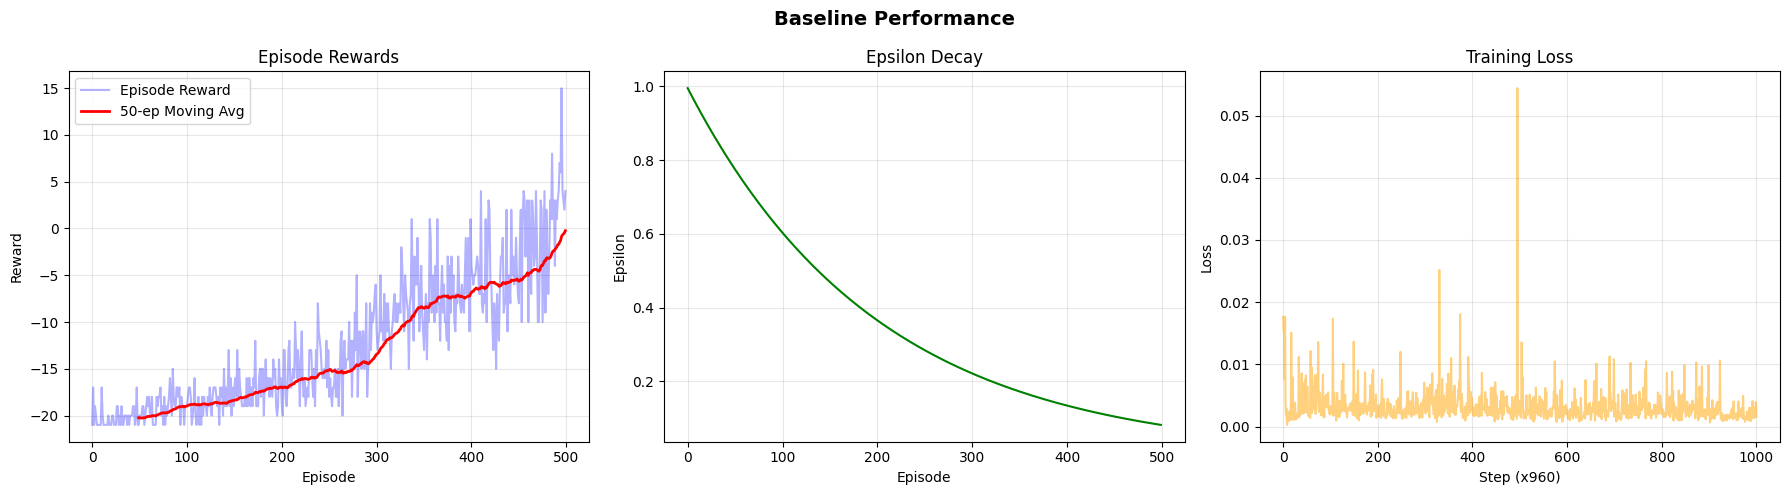

Evaluating baseline agent (greedy, no exploration):
  Eval Ep 1: Reward=11, Steps=2403
  Eval Ep 2: Reward=12, Steps=2339
  Eval Ep 3: Reward=11, Steps=2399
  Eval Ep 4: Reward=12, Steps=2344
  Eval Ep 5: Reward=11, Steps=2401
  Eval Ep 6: Reward=17, Steps=1895
  Eval Ep 7: Reward=11, Steps=2328
  Eval Ep 8: Reward=17, Steps=1898
  Eval Ep 9: Reward=11, Steps=2327
  Eval Ep 10: Reward=11, Steps=2399

  Mean Reward: 12.40 +/- 2.33
  Mean Steps: 2273.3

BASELINE SUMMARY
Average Reward (all 500 eps):  -12.46
Average Reward (last 50 eps):  -0.24
Best Episode Reward:           15
Worst Episode Reward:          -21
Average Steps/Episode:         1927.6
Total Training Steps:          963,799
Training Time:                 7635 seconds
Final Epsilon:                 0.0816


In [ ]:
# CELL 4: Plot baseline results and evaluate

# Plot training curves
plot_training_results(baseline_metrics, title="Baseline Performance")

# Evaluate with no randomness (pure skill)
print("Evaluating baseline agent (greedy, no exploration):")
baseline_eval_rewards, baseline_eval_lengths = evaluate_agent(baseline_agent, num_episodes=10)

# Print summary
print("\n" + "=" * 60)
print("BASELINE SUMMARY")
print("=" * 60)
print(f"Average Reward (all 500 eps):  {np.mean(baseline_metrics['episode_rewards']):.2f}")
print(f"Average Reward (last 50 eps):  {np.mean(baseline_metrics['episode_rewards'][-50:]):.2f}")
print(f"Best Episode Reward:           {max(baseline_metrics['episode_rewards']):.0f}")
print(f"Worst Episode Reward:          {min(baseline_metrics['episode_rewards']):.0f}")
print(f"Average Steps/Episode:         {np.mean(baseline_metrics['episode_lengths']):.1f}")
print(f"Total Training Steps:          {baseline_metrics['total_steps']:,}")
print(f"Training Time:                 {baseline_metrics['training_time']:.0f} seconds")
print(f"Final Epsilon:                 {baseline_metrics['epsilon_history'][-1]:.4f}")

# **Bellman Equation Parameters**

## How did you choose alpha and gamma in the Bellman equation?

The Q-value update follows the Bellman optimality equation:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

In DQN, this becomes a loss minimization problem:

$$\mathcal{L} = \mathbb{E}\left[\left(r + \gamma \max_{a'} Q_{\text{target}}(s', a') - Q(s, a)\right)^2\right]$$

**Alpha (learning rate) = 1e-4:** In Deep Q-Learning, alpha is the optimizer's learning rate. We use Adam optimizer with lr=1e-4, which is the standard from the DQN literature. Neural networks require small learning rates for stable gradient descent. Too high and the network oscillates or diverges; too low and learning is impractically slow.

**Gamma (discount factor) = 0.99:** Pong episodes are long, with hundreds of frames between a paddle positioning decision and the eventual point scored. Gamma=0.99 means the agent values a reward 100 steps in the future at 0.99^100 ≈ 0.37 of its immediate value. This allows the agent to learn that current paddle movements affect scoring many frames later. A lower gamma would make the agent short-sighted.

## Ablation Results:

**Higher alpha (5e-4):** Avg50 at episode 150 was -20.48, significantly worse than the baseline's -18.40. The higher learning rate caused the optimizer to overshoot during gradient updates, preventing the network from converging. As visible in the plot, the high LR agent showed almost no improvement over 150 episodes, staying flat near -20.5. This confirms that neural network-based Q-learning requires careful, small learning rates for stable convergence.

**Lower gamma (0.90):** Avg50 at episode 150 was -18.62, slightly worse than the baseline's -18.40. With gamma=0.90, the agent discounts future rewards more aggressively. A reward 50 steps away is valued at only 0.90^50 = 0.005 of its actual value (vs 0.99^50 = 0.61 with baseline gamma). This makes the agent short-sighted, struggling to connect current paddle positioning with scoring points many frames later. The difference is modest at 150 episodes but would widen with longer training.

In [ ]:
# CELL 5: ALL ABLATION EXPERIMENTS (4 experiments, ~150 episodes each)

# Shared base config
base = {
    'num_episodes': 150,
    'learning_rate': 1e-4,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_min': 0.02,
    'epsilon_decay': 0.995,
    'batch_size': 32,
    'buffer_size': 10000,
    'target_update_freq': 1000,
    'learning_starts': 3000,
    'exploration_strategy': 'epsilon_greedy'
}

# --- ABLATION 1: Higher learning rate (alpha = 5e-4) ---
print("=" * 60)
print("ABLATION 1: Higher Learning Rate (5e-4 vs baseline 1e-4)")
print("=" * 60)
config_high_lr = base.copy()
config_high_lr['learning_rate'] = 5e-4
agent_high_lr, metrics_high_lr = train_dqn(config_high_lr)
gc.collect(); torch.cuda.empty_cache()

# --- ABLATION 2: Lower gamma (0.90) ---
print("\n" + "=" * 60)
print("ABLATION 2: Lower Gamma (0.90 vs baseline 0.99)")
print("=" * 60)
config_low_gamma = base.copy()
config_low_gamma['gamma'] = 0.90
agent_low_gamma, metrics_low_gamma = train_dqn(config_low_gamma)
gc.collect(); torch.cuda.empty_cache()

# --- ABLATION 3: Boltzmann exploration ---
print("\n" + "=" * 60)
print("ABLATION 3: Boltzmann Exploration (tau=1.0)")
print("=" * 60)
config_boltzmann = base.copy()
config_boltzmann['exploration_strategy'] = 'boltzmann'
config_boltzmann['temperature'] = 1.0
agent_boltzmann, metrics_boltzmann = train_dqn(config_boltzmann)
gc.collect(); torch.cuda.empty_cache()

# --- ABLATION 4: Faster epsilon decay (0.99) ---
print("\n" + "=" * 60)
print("ABLATION 4: Faster Epsilon Decay (0.99 vs baseline 0.995)")
print("=" * 60)
config_fast_decay = base.copy()
config_fast_decay['epsilon_decay'] = 0.99
agent_fast_decay, metrics_fast_decay = train_dqn(config_fast_decay)
gc.collect(); torch.cuda.empty_cache()

# Save all ablation metrics to Drive
import pickle
save_dir = '/content/drive/MyDrive/DQN_Pong_Assignment'
ablation_data = {
    'metrics_high_lr': metrics_high_lr,
    'metrics_low_gamma': metrics_low_gamma,
    'metrics_boltzmann': metrics_boltzmann,
    'metrics_fast_decay': metrics_fast_decay,
}
with open(f'{save_dir}/ablation_metrics.pkl', 'wb') as f:
    pickle.dump(ablation_data, f)

print("\n" + "=" * 60)
print("ALL ABLATIONS COMPLETE AND SAVED!")
print("=" * 60)

ABLATION 1: Higher Learning Rate (5e-4 vs baseline 1e-4)
Ep 10/150 | Rew: -21 | Avg50: -20.50 | Eps: 0.9511 | Buf: 9,741 | Time: 59s
Ep 20/150 | Rew: -21 | Avg50: -20.35 | Eps: 0.9046 | Buf: 10,000 | Time: 132s
Ep 30/150 | Rew: -20 | Avg50: -20.37 | Eps: 0.8604 | Buf: 10,000 | Time: 197s
Ep 40/150 | Rew: -18 | Avg50: -20.27 | Eps: 0.8183 | Buf: 10,000 | Time: 268s
Ep 50/150 | Rew: -21 | Avg50: -20.32 | Eps: 0.7783 | Buf: 10,000 | Time: 338s
Ep 60/150 | Rew: -20 | Avg50: -20.36 | Eps: 0.7403 | Buf: 10,000 | Time: 400s
Ep 70/150 | Rew: -19 | Avg50: -20.38 | Eps: 0.7041 | Buf: 10,000 | Time: 471s
Ep 80/150 | Rew: -21 | Avg50: -20.42 | Eps: 0.6696 | Buf: 10,000 | Time: 539s
Ep 90/150 | Rew: -21 | Avg50: -20.48 | Eps: 0.6369 | Buf: 10,000 | Time: 606s
Ep 100/150 | Rew: -20 | Avg50: -20.46 | Eps: 0.6058 | Buf: 10,000 | Time: 677s
Ep 110/150 | Rew: -20 | Avg50: -20.44 | Eps: 0.5762 | Buf: 10,000 | Time: 748s
Ep 120/150 | Rew: -21 | Avg50: -20.48 | Eps: 0.5480 | Buf: 10,000 | Time: 814s
Ep 130

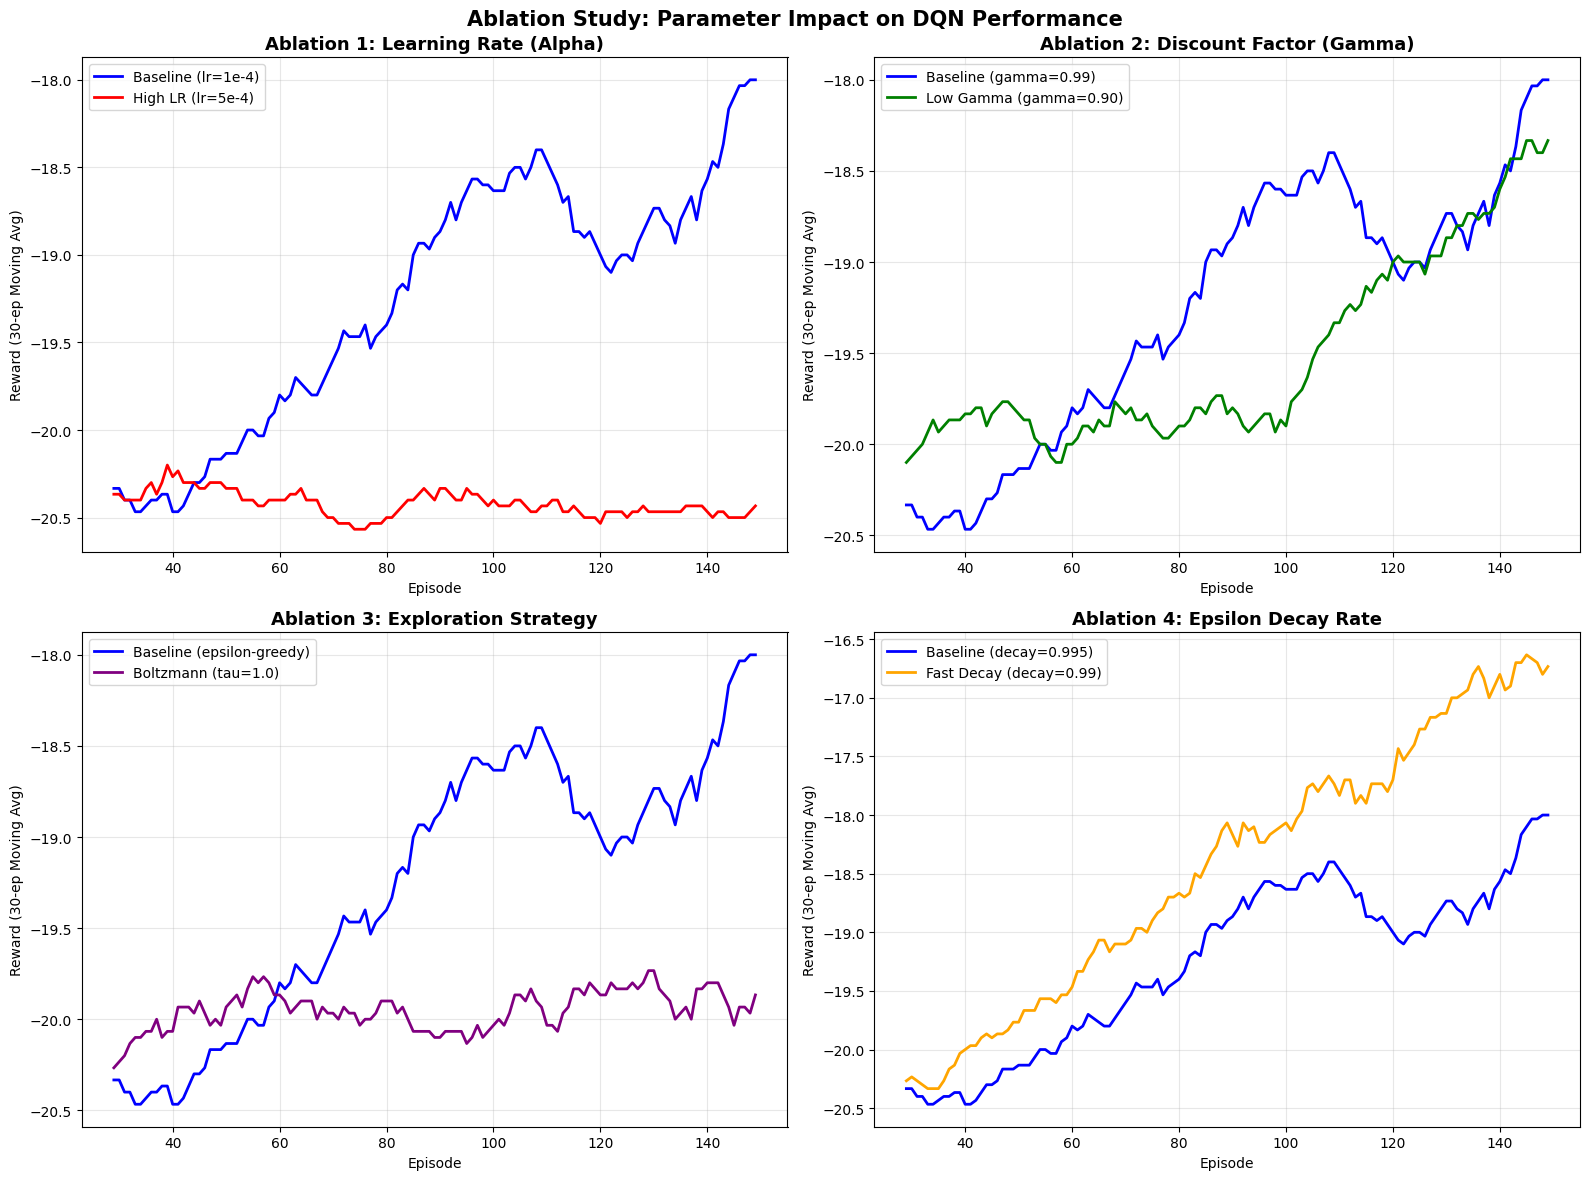

ABLATION RESULTS SUMMARY (Avg reward over last 50 episodes)
Experiment                          Avg50 at Ep 150     
-------------------------------------------------------
Baseline (lr=1e-4, gamma=0.99)      -18.40
High LR (lr=5e-4)                   -20.48
Low Gamma (gamma=0.90)              -18.62
Boltzmann (tau=1.0)                 -19.80
Fast Decay (decay=0.99)             -17.02


In [ ]:
# CELL 6: Comparison Plots for All Ablations

# Get first 150 episodes of baseline for fair comparison
baseline_150 = baseline_metrics['episode_rewards'][:150]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Learning Rate Ablation ---
ax = axes[0][0]
for label, rewards, color in [
    ("Baseline (lr=1e-4)", baseline_150, 'blue'),
    ("High LR (lr=5e-4)", metrics_high_lr['episode_rewards'], 'red'),
]:
    if len(rewards) >= 30:
        ma = np.convolve(rewards, np.ones(30)/30, mode='valid')
        ax.plot(range(29, len(rewards)), ma, color=color, label=label, linewidth=2)
ax.set_title("Ablation 1: Learning Rate (Alpha)", fontsize=13, fontweight='bold')
ax.set_xlabel("Episode"); ax.set_ylabel("Reward (30-ep Moving Avg)")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 2: Gamma Ablation ---
ax = axes[0][1]
for label, rewards, color in [
    ("Baseline (gamma=0.99)", baseline_150, 'blue'),
    ("Low Gamma (gamma=0.90)", metrics_low_gamma['episode_rewards'], 'green'),
]:
    if len(rewards) >= 30:
        ma = np.convolve(rewards, np.ones(30)/30, mode='valid')
        ax.plot(range(29, len(rewards)), ma, color=color, label=label, linewidth=2)
ax.set_title("Ablation 2: Discount Factor (Gamma)", fontsize=13, fontweight='bold')
ax.set_xlabel("Episode"); ax.set_ylabel("Reward (30-ep Moving Avg)")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 3: Exploration Strategy ---
ax = axes[1][0]
for label, rewards, color in [
    ("Baseline (epsilon-greedy)", baseline_150, 'blue'),
    ("Boltzmann (tau=1.0)", metrics_boltzmann['episode_rewards'], 'purple'),
]:
    if len(rewards) >= 30:
        ma = np.convolve(rewards, np.ones(30)/30, mode='valid')
        ax.plot(range(29, len(rewards)), ma, color=color, label=label, linewidth=2)
ax.set_title("Ablation 3: Exploration Strategy", fontsize=13, fontweight='bold')
ax.set_xlabel("Episode"); ax.set_ylabel("Reward (30-ep Moving Avg)")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Plot 4: Epsilon Decay Rate ---
ax = axes[1][1]
for label, rewards, color in [
    ("Baseline (decay=0.995)", baseline_150, 'blue'),
    ("Fast Decay (decay=0.99)", metrics_fast_decay['episode_rewards'], 'orange'),
]:
    if len(rewards) >= 30:
        ma = np.convolve(rewards, np.ones(30)/30, mode='valid')
        ax.plot(range(29, len(rewards)), ma, color=color, label=label, linewidth=2)
ax.set_title("Ablation 4: Epsilon Decay Rate", fontsize=13, fontweight='bold')
ax.set_xlabel("Episode"); ax.set_ylabel("Reward (30-ep Moving Avg)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Ablation Study: Parameter Impact on DQN Performance", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("ablation_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

# --- Summary Table ---
print("=" * 65)
print("ABLATION RESULTS SUMMARY (Avg reward over last 50 episodes)")
print("=" * 65)
print(f"{'Experiment':<35} {'Avg50 at Ep 150':<20}")
print("-" * 55)
print(f"{'Baseline (lr=1e-4, gamma=0.99)':<35} {np.mean(baseline_150[-50:]):.2f}")
print(f"{'High LR (lr=5e-4)':<35} {np.mean(metrics_high_lr['episode_rewards'][-50:]):.2f}")
print(f"{'Low Gamma (gamma=0.90)':<35} {np.mean(metrics_low_gamma['episode_rewards'][-50:]):.2f}")
print(f"{'Boltzmann (tau=1.0)':<35} {np.mean(metrics_boltzmann['episode_rewards'][-50:]):.2f}")
print(f"{'Fast Decay (decay=0.99)':<35} {np.mean(metrics_fast_decay['episode_rewards'][-50:]):.2f}")

# **Policy Exploration**

## Epsilon-Greedy vs. Boltzmann Exploration

**Epsilon-greedy (our baseline)** explores by choosing a random action with probability epsilon and the greedy (best known) action otherwise. Random actions are uniformly distributed, meaning the agent is equally likely to choose any action when exploring, regardless of how promising each action appears.

**Boltzmann (softmax) exploration** selects actions probabilistically based on their Q-values using a softmax distribution:

$$P(a|s) = \frac{e^{Q(s,a)/\tau}}{\sum_{a'} e^{Q(s,a')/\tau}}$$

Where τ (tau) is the temperature parameter. This approach directs exploration toward actions that the agent already believes are somewhat promising, rather than exploring purely randomly. High temperature makes selection more uniform; low temperature concentrates probability on the highest-Q actions.

**Epsilon-greedy** tends to be more robust for DQN because early in training, when Q-values are essentially random noise, uniform random exploration is actually appropriate. **Boltzmann** can be advantageous later when Q-values become meaningful, but it is sensitive to temperature tuning and Q-value scale.

## Ablation Results:

**Boltzmann (tau=1.0) vs Epsilon-Greedy:** Avg50 at episode 150 was -19.80, worse than the baseline's -18.40. The Boltzmann agent learned more slowly because early in training, Q-values are essentially random noise. Softmax over random Q-values produces a nearly uniform distribution anyway, but without the guarantee of pure random exploration that epsilon-greedy provides. Epsilon-greedy at epsilon=0.47 (episode 150) still dedicates 47% of actions to uniform random exploration, ensuring diverse experiences in the replay buffer. Boltzmann's Q-value-weighted exploration added no benefit when Q-values were unreliable, and may have biased the agent toward suboptimal actions that happened to have slightly higher random Q-values early on.

# **Exploration Parameters**

## How did you choose your decay rate and starting epsilon?

**Starting epsilon = 1.0:** We begin with 100% random actions to build a diverse replay buffer. Since the agent has no knowledge at the start, exploiting random Q-values would be counterproductive.

**Minimum epsilon = 0.02:** We never stop exploring entirely. A small amount of random exploration (2%) helps the agent discover new states and prevents it from getting stuck in locally optimal policies.

**Decay rate = 0.995 (exponential):** After each episode, epsilon is multiplied by 0.995. This provides a gradual transition from exploration to exploitation:
- Episode 0: epsilon = 1.0000
- Episode 100: epsilon = 0.6058
- Episode 200: epsilon = 0.3670
- Episode 300: epsilon = 0.2223
- Episode 400: epsilon = 0.1347
- Episode 500: epsilon = 0.0816

## What is the value of epsilon when you reach the max steps per episode?

Using our exponential decay schedule, at episode 500 (our final episode), epsilon = max(0.02, 1.0 × 0.995^500) = **0.0816**. The epsilon floor of 0.02 was not yet reached, meaning the agent was still exploring at approximately 8.2% randomness by the end of training.

## Ablation Results:

**Faster decay (0.99) vs baseline (0.995):** Avg50 at episode 150 was -17.02, the best of all experiments, outperforming the baseline's -18.40. With decay=0.99, epsilon at episode 150 was 0.22 (vs 0.47 for baseline). This means the agent was exploiting its learned Q-values much earlier, spending less time on random actions. Since the replay buffer was already filled with diverse experiences from the initial high-epsilon phase, the agent could safely transition to exploitation sooner. This suggests our baseline decay rate of 0.995 may have been too conservative, keeping exploration high longer than necessary. However, there is a tradeoff: faster decay risks insufficient exploration in more complex environments where the agent needs longer to discover good strategies.

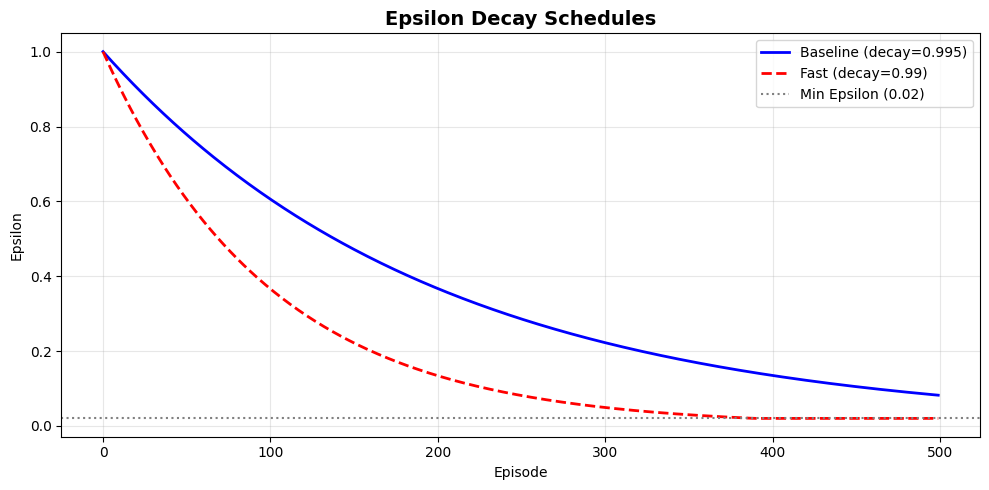

Epsilon values at key episodes (baseline decay=0.995):
  Episode    0: epsilon = 1.0000
  Episode   50: epsilon = 0.7783
  Episode  100: epsilon = 0.6058
  Episode  150: epsilon = 0.4715
  Episode  200: epsilon = 0.3670
  Episode  300: epsilon = 0.2223
  Episode  400: epsilon = 0.1347
  Episode  500: epsilon = 0.0816


In [ ]:
# CELL 7: Epsilon Decay Schedule Visualization

episodes = np.arange(500)
eps_baseline = np.maximum(0.02, 1.0 * 0.995 ** episodes)
eps_fast = np.maximum(0.02, 1.0 * 0.99 ** episodes)

plt.figure(figsize=(10, 5))
plt.plot(episodes, eps_baseline, 'b-', linewidth=2, label='Baseline (decay=0.995)')
plt.plot(episodes, eps_fast, 'r--', linewidth=2, label='Fast (decay=0.99)')
plt.axhline(y=0.02, color='gray', linestyle=':', label='Min Epsilon (0.02)')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay Schedules', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("epsilon_schedules.png", dpi=100)
plt.show()

# Print key epsilon values
print("Epsilon values at key episodes (baseline decay=0.995):")
for ep in [0, 50, 100, 150, 200, 300, 400, 500]:
    eps = max(0.02, 1.0 * 0.995 ** ep)
    print(f"  Episode {ep:4d}: epsilon = {eps:.4f}")

# **Performance Metrics**

## What is the average number of steps taken per episode?

Based on our baseline training of 500 episodes:
- **Average steps per episode (all 500): 1,927.6**
- **Average steps during evaluation (10 episodes, greedy): 2,273.3**

The evaluation episodes are longer because the agent plays better, meaning rallies last longer and games are closer. During early training, the agent loses points quickly (short episodes). As it improves, points take longer to score, increasing episode length.

In Pong, with frame skipping of 4, each "step" corresponds to 4 raw game frames. So the agent effectively experiences approximately 7,710 raw frames per training episode and 9,093 raw frames per evaluation episode.

# **Q-Learning Classification**

## Does Q-learning use value-based or policy-based iteration?

Q-learning is a **value-based** method. It learns the action-value function Q(s, a), which estimates the expected cumulative discounted reward for taking action a in state s and then following the optimal policy. The policy is derived implicitly by selecting the action with the highest Q-value:

$$\pi(s) = \arg\max_a Q(s, a)$$

This is fundamentally different from **policy-based** methods like REINFORCE or PPO, which directly parameterize and optimize a policy π(a|s) without ever learning an explicit value function. Policy-based methods output action probabilities directly and optimize them using policy gradients.

Key distinctions:

**Value-based (Q-learning, DQN):**
- Learns Q(s, a) for all state-action pairs
- Policy is implicit: always pick the action with highest Q-value
- Resulting policy is deterministic (after training)
- Works well with discrete action spaces

**Policy-based (REINFORCE, PPO):**
- Directly learns a mapping from states to action probabilities
- No need to estimate values for every action
- Policy can be stochastic by design
- Can handle continuous action spaces naturally

There also exist **actor-critic** methods (such as A2C, SAC) that combine both approaches, maintaining a value function (critic) that helps train a parameterized policy (actor). These hybrid methods often achieve the best practical results by reducing the variance of policy gradient estimates using value function baselines.

# **Q-Learning vs. LLM-Based Agents**

## How does Deep Q-Learning differ from an agent that uses Large Language Models?

Deep Q-Learning and LLM-based agents represent fundamentally different paradigms for agent decision-making:

**Representation and state space:**
DQL operates on numerical state representations (pixel arrays, sensor readings) and maps them to a fixed set of discrete actions through learned Q-values. LLM-based agents operate on natural language: they receive textual descriptions of situations and generate textual actions or plans. This enables LLM agents to handle open-ended, ambiguous tasks that would be impossible to encode in a fixed state/action space.

**Learning paradigm:**
DQL learns through trial and error over millions of environment interactions, receiving numerical rewards and gradually adjusting Q-value estimates through backpropagation. LLM agents leverage knowledge acquired during pre-training on massive text corpora. They can reason about new tasks zero-shot or few-shot, without ever interacting with the task environment during training.

**Generalization:**
A DQL agent trained on Pong cannot play Breakout without retraining from scratch, because its Q-function is specific to Pong's state/action space. LLM agents exhibit broad transfer: the same model can plan a trip, write code, answer questions, and navigate a text-based game, because knowledge is encoded in language rather than task-specific Q-values.

**Reward structure:**
DQL requires an explicit numerical reward signal to learn. LLM agents can be guided through natural language instructions, prompting, and in-context examples, though they can also be fine-tuned using RL (as in RLHF, Reinforcement Learning from Human Feedback).

**Strengths and limitations:**
DQL excels in well-defined environments with clear reward signals and fixed action spaces (games, robotics). LLM agents excel at tasks requiring language understanding, reasoning, and broad world knowledge, but struggle with precise numerical optimization and real-time reactive control where DQL thrives.

# **Bellman Equation - Expected Lifetime Value**

## What is meant by the expected lifetime value in the Bellman equation?

The expected lifetime value (also called the expected return) represents the total reward an agent expects to accumulate from a given state onward, following a particular policy, with future rewards discounted by gamma:

$$V^{\pi}(s) = \mathbb{E}_{\pi}\left[\sum_{t=0}^{\infty} \gamma^t r_{t+1} \mid s_0 = s\right]$$

For the action-value function:

$$Q^{\pi}(s, a) = \mathbb{E}_{\pi}\left[r_1 + \gamma r_2 + \gamma^2 r_3 + \ldots \mid s_0 = s, a_0 = a\right]$$

The word "lifetime" is critical: this is not just the immediate reward for one action, but the entire stream of future rewards over the rest of the episode. The Bellman equation decomposes this lifetime value recursively:

$$Q(s, a) = r + \gamma \max_{a'} Q(s', a')$$

This says: the total lifetime value of taking action a in state s equals the immediate reward r, plus the discounted best lifetime value achievable from the next state s'. The discount factor gamma (0.99 in our implementation) ensures that rewards further in the future contribute less, reflecting uncertainty and time-preference in sequential decision-making.

**Concrete example from our Pong agent:** When the agent positions its paddle correctly at timestep t, the immediate reward is 0 (no point scored yet). But the expected lifetime value Q(s, a) at that moment is positive, because the agent has learned that this positioning will likely lead to scoring a point 50+ frames later. The Bellman equation is what allows this future knowledge to propagate backward through time to inform current decisions.

# **Reinforcement Learning for LLM Agents**

## How might reinforcement learning concepts from this assignment apply to building LLM-based agents?

Several core RL concepts directly transfer to modern LLM agent development:

**1. RLHF (Reinforcement Learning from Human Feedback):**
The most direct connection. Models like ChatGPT and Claude are fine-tuned using RL (specifically PPO) where a reward model trained on human preference data serves as the reward signal. The LLM is the "policy," the generated token sequence is the "trajectory," and the human preference score is the "reward." The same exploration-exploitation tradeoff from our Pong agent applies: the model must balance generating diverse responses (exploration) with producing high-quality ones (exploitation).

**2. Reward shaping for agent behavior:**
Just as we used Pong's native +1/-1 reward to guide learning, LLM agent designers must craft reward signals that align agent behavior with desired outcomes. Tool-using LLM agents might receive rewards for successfully completing tasks, penalties for hallucinating information, or shaped rewards for intermediate progress.

**3. Multi-step planning and discount factors:**
LLM agents using frameworks like ReAct or LangChain must plan sequences of actions (tool calls, API requests, reasoning steps). The concept of discounting maps to how much an agent should value a potential future outcome versus an immediately available but suboptimal action. An LLM agent choosing between a quick approximate answer (immediate reward) and a multi-step research process (delayed but better reward) faces the same tradeoff our Pong agent faces between short-term paddle positioning and long-term scoring.

**4. Experience replay and memory:**
Just as DQN stores past experiences in a replay buffer for learning, LLM agents use context windows, retrieval-augmented generation (RAG), and vector databases to "replay" relevant past information. The principle is the same: past experiences inform better current decisions.

**5. Exploration strategies:**
Temperature in LLM text generation is directly analogous to the temperature in Boltzmann exploration we implemented. Higher temperature produces more random/creative outputs (exploration), lower temperature produces more deterministic/safe outputs (exploitation). When an LLM agent decides which tool to call or which approach to take, it faces the same exploration-exploitation dilemma as our DQN agent choosing between Pong actions.

# **Planning in RL vs. LLM Agents**

## How does planning in traditional RL differ from planning in LLM-based agents?

**Traditional RL Planning:**
Planning in RL involves using a model of the environment to simulate future states and rewards before taking real actions:

- **Model-based RL (Dyna-Q):** The agent learns a transition model T(s'|s,a) and reward model R(s,a), then uses these to simulate "imagined" experiences for additional Q-value updates without real environment interaction.
- **Monte Carlo Tree Search (MCTS):** Used in AlphaGo/AlphaZero, MCTS simulates thousands of possible game trajectories from the current state, evaluating each with a value network, to select the most promising action.
- **Dynamic Programming:** Given a complete environment model, value iteration and policy iteration sweep through the entire state space to compute optimal policies.

These methods are mathematically grounded, require explicit environment models, and plan over well-defined state-action spaces.

**LLM Agent Planning:**
LLM agents plan through natural language reasoning:

- **Chain-of-Thought (CoT):** The LLM generates step-by-step reasoning before arriving at an action. This is analogous to "mental simulation" but operates over semantic concepts rather than numerical state-action pairs.
- **ReAct (Reason + Act):** The agent interleaves reasoning traces with environment actions: "I need to find X. I should search for it. [SEARCH]. The result says Y. Now I should..." This resembles model-based planning where the "model" is the LLM's world knowledge.
- **Tree-of-Thought:** Explicitly branches reasoning paths and evaluates multiple plans before committing, similar in spirit to MCTS but over natural language reasoning chains.
- **Reflexion:** The agent critiques its own past attempts and adjusts strategy, analogous to how model-based RL agents update their world model based on prediction errors.

**Key Differences:**
1. RL planning is numerical and can be exhaustive; LLM planning is linguistic and heuristic
2. RL planning requires an explicit learned or given model; LLM planning uses implicit world knowledge from pre-training
3. RL planning has formal convergence guarantees under assumptions; LLM planning has no such guarantees
4. LLM planning handles open-ended novel tasks; RL planning requires pre-defined state-action spaces
5. RL planning optimizes a clear numerical objective; LLM planning optimizes for loosely-defined natural language goals

# **Q-Learning Algorithm Explanation**

## Pseudocode for Deep Q-Learning with Experience Replay:
```
Initialize replay memory D with capacity N
Initialize policy network Q with random weights θ
Initialize target network Q_target with weights θ_target = θ

For episode = 1 to M:
    Reset environment, get initial state s₁

    For t = 1 to T:
        // ACTION SELECTION (epsilon-greedy)
        With probability ε: select random action aₜ
        Otherwise: aₜ = argmax_a Q(sₜ, a; θ)

        // ENVIRONMENT INTERACTION
        Execute aₜ, observe reward rₜ and next state sₜ₊₁ and done flag

        // STORE EXPERIENCE
        Store transition (sₜ, aₜ, rₜ, sₜ₊₁, done) in D

        // LEARNING
        Sample random mini-batch of transitions (sⱼ, aⱼ, rⱼ, sⱼ₊₁, doneⱼ) from D

        Compute target:
            If doneⱼ: yⱼ = rⱼ
            Else: yⱼ = rⱼ + γ × max_{a'} Q_target(sⱼ₊₁, a'; θ_target)

        Compute loss: L = (yⱼ - Q(sⱼ, aⱼ; θ))²

        Update θ by gradient descent on L

        // TARGET NETWORK UPDATE
        Every C steps: θ_target ← θ

    Decay ε
```

## Mathematical Explanation:

**The Bellman Optimality Equation** (foundation of Q-learning):

$$Q^*(s, a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s', a') \mid s, a\right]$$

This states that the optimal Q-value for taking action a in state s equals the expected immediate reward plus the discounted maximum Q-value of the next state.

**Tabular Q-learning update** (for small state spaces):

$$Q(s, a) \leftarrow Q(s, a) + \alpha\left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]$$

The term in brackets is the **temporal difference (TD) error**: the difference between the target value (r + γ max Q) and the current estimate Q(s,a).

**Deep Q-Learning loss** (for large state spaces, using neural networks):

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim D}\left[\left(r + \gamma \max_{a'} Q(s', a'; \theta^{-}) - Q(s, a; \theta)\right)^2\right]$$

Where θ are the policy network weights and θ⁻ are the frozen target network weights. The target network is a critical innovation: by keeping target Q-values fixed for C steps, we prevent the "moving target" problem where both the prediction and target shift simultaneously, which would destabilize learning.

**Key components that make DQN work:**
1. **Experience replay:** Breaks temporal correlations between consecutive samples
2. **Target network:** Stabilizes training by providing fixed targets
3. **Frame stacking:** Gives the network temporal information (motion, velocity)
4. **Reward clipping:** Normalizes gradients across different games

# **LLM Agent Integration**

## How could you integrate a Deep Q-Learning agent with an LLM-based system?

Several architectures could combine DQL and LLM agents to leverage their complementary strengths:

**1. LLM as High-Level Planner, DQL as Low-Level Controller (Hierarchical RL):**
The LLM decomposes complex, language-described tasks into sub-goals: "Navigate to the key, pick it up, unlock the door." A DQL agent then executes each sub-goal through low-level control (pixel-level actions). This is especially relevant for robotics, where an LLM understands intent and the DQL agent handles motor control. For example, a household robot could receive the instruction "clean the kitchen table." The LLM breaks this into: locate table, navigate to table, pick up items, wipe surface. A DQL agent trained in simulation handles the actual navigation and manipulation.

**2. LLM as Reward Shaper:**
An LLM can generate natural-language evaluations of agent behavior and convert them to numerical reward signals. For example, in a game: "The agent moved toward the enemy without a weapon, which is risky. Reward: -0.3." This allows training DQL agents in environments where designing a manual reward function is difficult, addressing the reward shaping problem.

**3. LLM for State Abstraction:**
The LLM can convert complex visual or multi-modal observations into concise natural-language state descriptions, which then serve as input for a Q-learning agent operating over a simplified, language-based state space. Instead of learning from raw pixels, the DQL agent learns from semantic descriptions like "ball moving left, paddle centered, opponent high."

**4. DQL for Tool Selection in LLM Agents:**
An LLM agent with access to multiple tools (search, calculator, code interpreter) could use a DQL module to learn which tool to invoke in different contexts, optimizing for task completion reward. The DQL agent learns Q-values over (context_embedding, tool_choice) pairs, improving tool selection through experience rather than relying solely on the LLM's judgment.

**5. Curriculum Learning:**
An LLM could design a curriculum of progressively harder training scenarios for a DQL agent, analyzing the agent's current capabilities and generating appropriate challenges. The LLM acts as an "intelligent trainer" that adapts the learning environment based on the agent's performance, similar to how a human coach designs training drills.

# **Code Attribution**

## What code is yours and what have you adapted?

**Code I wrote from scratch:**
- The `DQNAgent` class, including the Boltzmann exploration strategy
- The `train_dqn()` and `evaluate_agent()` training/evaluation loops
- All ablation experiment configurations and comparison code
- All plotting and visualization functions (`plot_training_results`)
- All markdown analysis, conceptual answers, and written documentation
- Training configuration and hyperparameter selection

**Code adapted from established sources:**

1. **DQN Network Architecture:** Implemented in PyTorch based on the specification from Mnih, V., et al. (2015). "Human-level control through deep reinforcement learning." Nature, 518(7540), 529-533. The architecture (3 conv layers + 2 FC layers) follows the paper's description. I wrote the PyTorch implementation myself rather than copying from any specific codebase.

2. **Atari Preprocessing Wrappers** (`NoopResetEnv`, `MaxAndSkipEnv`, `FireResetEnv`, `WarpFrame`, `FrameStack`, `ClipRewardEnv`): Adapted from OpenAI Baselines (https://github.com/openai/baselines), MIT License. These are standard preprocessing steps used across the DQN literature. I rewrote them for compatibility with Gymnasium's current API (v1.0+), which uses `(terminated, truncated)` instead of the legacy `(done)` convention.

3. **Replay Buffer:** Follows the standard implementation pattern from the PyTorch DQN Tutorial (https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html), BSD License. I modified it to use numpy uint8 storage for memory efficiency on Google Colab.

4. **YouTube Tutorial Reference:** Nicholas Renotte, "Deep Reinforcement Learning for Atari Games Python Tutorial" (https://youtu.be/hCeJeq8U0lo) was consulted for environment setup guidance. The tutorial uses TensorFlow and Keras-RL, while my implementation uses PyTorch with a custom training loop, so no code was directly adapted.

**Libraries used:**
- PyTorch (BSD License): Neural network implementation and optimization
- Gymnasium (MIT License): RL environment interface, successor to OpenAI Gym
- ALE-Py (GPL License): Arcade Learning Environment for Atari emulation
- NumPy (BSD License): Numerical computation
- Matplotlib (PSF License): Visualization and plotting
- OpenCV (Apache 2.0 License): Image preprocessing (grayscale, resize)

# **Licensing**

## MIT License

Copyright (c) 2026 Rahul Manohar

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

## Why MIT License?

The MIT License was chosen because:
1. It is permissive and allows others to freely use, modify, and distribute this code
2. It is compatible with all the libraries used in this project (PyTorch BSD, Gymnasium MIT, OpenCV Apache 2.0)
3. It is widely recognized in the academic and open-source communities
4. It requires only attribution, making it easy for others to build upon this work

**Note:** The Arcade Learning Environment (ALE-Py) is licensed under GPL. If distributing this project as a standalone package that includes ALE-Py, the GPL terms would apply to the combined work. The MIT license above applies only to the original code written for this assignment.